In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split,RandomizedSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

df=pd.read_csv("../../data/final/kidney_final.csv")
X=df.drop("Diagnosis",axis=1)
y=df["Diagnosis"]

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,stratify=y,random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [2]:

models={
"Logistic Regression":LogisticRegression(max_iter=1000),
"Decision Tree":DecisionTreeClassifier(random_state=42),
"Random Forest":RandomForestClassifier(random_state=42),
"SVM":SVC(probability=True),
"KNN":KNeighborsClassifier(),
"Naive Bayes":GaussianNB(),
"XGBoost":XGBClassifier(eval_metric="logloss",random_state=42),
"LightGBM":LGBMClassifier(random_state=42,verbosity=-1),
"CatBoost":CatBoostClassifier(verbose=0,random_state=42)
}

results=[]

for n,m in models.items():
    if n in ["Logistic Regression","SVM","KNN","Naive Bayes"]:
        m.fit(X_train_scaled,y_train)
        pred=m.predict(X_test_scaled)
        proba=m.predict_proba(X_test_scaled)[:,1]
    else:
        m.fit(X_train,y_train)
        pred=m.predict(X_test)
        proba=m.predict_proba(X_test)[:,1]

    results.append([n,
                    accuracy_score(y_test,pred),
                    precision_score(y_test,pred),
                    recall_score(y_test,pred),
                    f1_score(y_test,pred),
                    roc_auc_score(y_test,proba)])

results=pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1","ROC_AUC"])
results=results.sort_values("Accuracy",ascending=False)
display(results)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
8,CatBoost,0.930723,0.929878,1.000000,0.963665,0.796114
7,LightGBM,0.924699,0.932099,0.990164,0.960254,0.778628
2,Random Forest,0.921687,0.921450,1.000000,0.959119,0.766667
0,Logistic Regression,0.918675,0.934375,0.980328,0.956800,0.804493
3,SVM,0.918675,0.918675,1.000000,0.957614,0.792957
5,Naive Bayes,0.915663,0.936909,0.973770,0.954984,0.771949
4,KNN,0.912651,0.918182,0.993443,0.954331,0.498846
6,XGBoost,0.912651,0.933962,0.973770,0.953451,0.787492
1,Decision Tree,0.858434,0.935811,0.908197,0.921797,0.602247


In [3]:

param_dist={
"n_estimators":[100,200,300],
"max_depth":[5,10,20,None],
"min_samples_split":[2,5,10],
"min_samples_leaf":[1,2,4]
}

search=RandomizedSearchCV(
RandomForestClassifier(random_state=42),
param_dist,
cv=5,
n_iter=20,
n_jobs=-1,
random_state=42)

search.fit(X_train,y_train)

best_model=search.best_estimator_
pred=best_model.predict(X_test)
proba=best_model.predict_proba(X_test)[:,1]

print(search.best_params_)
print("Accuracy:",accuracy_score(y_test,pred))


{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Accuracy: 0.9216867469879518


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.04      0.07        27
           1       0.92      1.00      0.96       305

    accuracy                           0.92       332
   macro avg       0.96      0.52      0.52       332
weighted avg       0.93      0.92      0.89       332



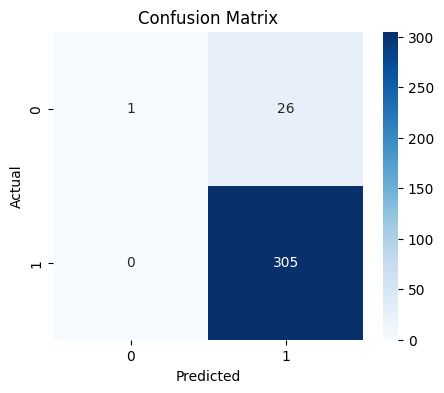

In [4]:

print("Classification Report")
print(classification_report(y_test,pred))

cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


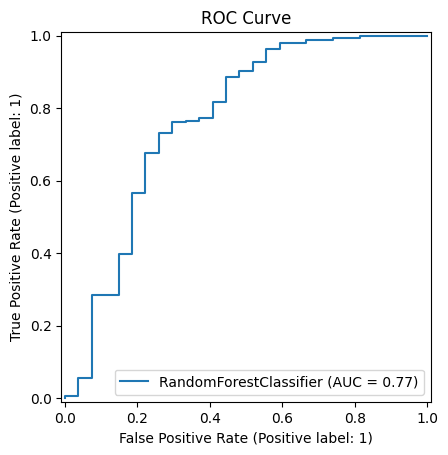

In [5]:

RocCurveDisplay.from_estimator(best_model,X_test,y_test)
plt.title("ROC Curve")
plt.show()


In [6]:

cv_score=cross_val_score(best_model,X,y,cv=5,scoring="accuracy")

print("Cross Validation Scores:",cv_score)
print("Mean Accuracy:",cv_score.mean())


Cross Validation Scores: [0.9186747  0.9186747  0.92168675 0.9186747  0.918429  ]
Mean Accuracy: 0.9192279692789285


In [7]:

joblib.dump(best_model,"../../models/best_model_kidney.pkl")
joblib.dump(scaler,"../../models/scaler_kidney.pkl")
print("Model and scaler saved.")


Model and scaler saved.
